In [1]:
from fenics import *
import matplotlib.pyplot as plt

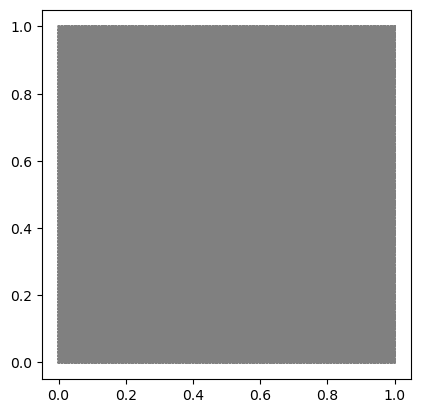

In [2]:
# Definir el dominio y malla
m = 100
mesh = UnitSquareMesh(m, m)

plot(mesh)

In [3]:
# Definir el espacio funcional de prueba (H)
fspace = FunctionSpace(mesh, "Lagrange",  1)

# Condición de frontera (u=0 en todo el borde)
def funcion_bool(x, on_boundary):
    return on_boundary
condicion_borde = DirichletBC(fspace, Constant(0.0), funcion_bool)

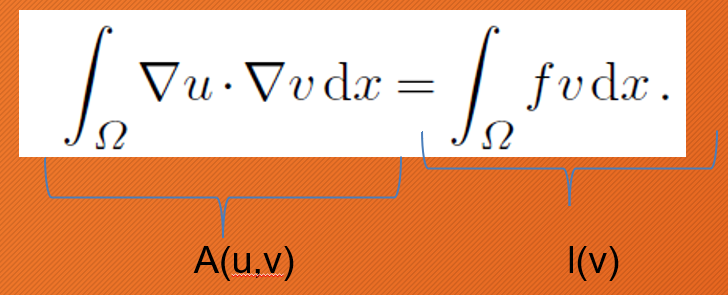

In [4]:
# Define la función u (solución) y v (función prueba)
u = TrialFunction(fspace)
v = TestFunction(fspace)
u_sol = Function(fspace)

# Función f (rhs)
f = Expression('x[0]*x[1]', degree = 1)

# Decirle a Fenics la forma variacional: a(u,v) = lv(f)
# a(u,v) - lv(f) = 0
a = dot(grad(u), grad(v)) * dx    
lv = f * v * dx

# Solución con elementos finitos:
solve(a == lv, u_sol, condicion_borde)

Solving linear variational problem.


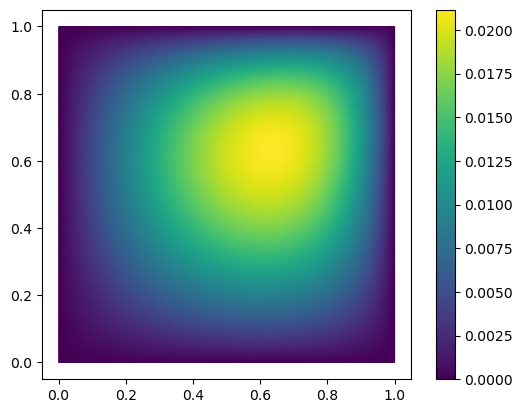

In [5]:
# Visualización
c = plot(u_sol, mode="color")
plt.colorbar(c)

In [6]:
#  Verificación
print( "Verificando u(0.5,0.5) = " + str( round( u_sol(0.5,0.5) , 6) ) )
print( "Verificando u(0.23,0.15) = " + str( round( u_sol(0.23,0.15) , 6) ) )

Verificando u(0.5,0.5) = 0.018418
Verificando u(0.23,0.15) = 0.003672


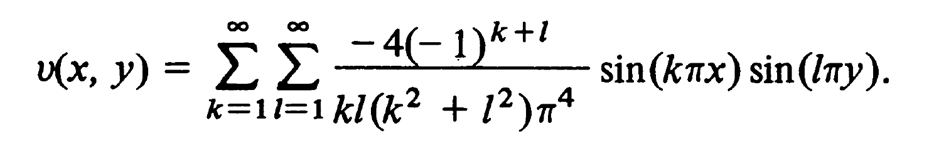

In [7]:
import numpy as np

def Poisson (x,y):
    N=500 # ya que hay 2 sumatorias infinitas, le ponemos un límite superior
    u=0
    for k in range (1,N+1):
        for l in range (1,N+1):
            ukl=-4*np.power(-1,k+l)/(k*l*(k**2+l**2)*np.power(np.pi,4))
            u=u+ukl*np.sin(k*np.pi*x)*np.sin(l*np.pi*y)
    return u

-Poisson(0.5, 0.5)

0.018417838062454398

In [8]:
uff = 0.0184145
ufe = 0.0184170

u_exacto = -Poisson(0.5, 0.5)  # Solución analítica

error_ff = abs(uff - u_exacto) / abs(u_exacto)
error_fe = abs(ufe - u_exacto) / abs(u_exacto)

print(f"Solución analítica: {u_exacto:.7f}")
print(f"Error relativo FreeFem++: {error_ff:.8f} ({error_ff * 100:.6f}%)")
print(f"Error relativo FEniCS:     {error_fe:.8f} ({error_fe * 100:.6f}%)")


Solución analítica: 0.0184178
Error relativo FreeFem++: 0.00018124 (0.018124%)
Error relativo FEniCS:     0.00004550 (0.004550%)


In [1]:
import pandas as pd

In [2]:
u_fe = [0.01841231343719489, 0.018416946274773395, 0.018417615018958666, 0.018417782476876934, 0.018417824358378777]
e_fe = [5.524625259507171e-06, 8.917876810031478e-07, 2.2304349573190607e-07, 5.558557746379589e-08, 1.3704075620818434e-08]
mallas = [20, 50, 100, 200, 400]

u_ff = [0.018397, 0.0184145, 0.018417, 0.0184176, 0.0184178]
e_ff = [0.018417838062454398 - x for x in u_ff]

df = pd.DataFrame({"malla": mallas, "u_fe": u_fe, "e_fe": e_fe, "u_ff": u_ff, "e_ff": e_ff})
df

,malla,u_fe,e_fe,u_ff,e_ff
0,20,0.018412,5.524625e-06,0.018397,2.083806e-05
1,50,0.018417,8.917877e-07,0.018415,3.338062e-06
2,100,0.018418,2.230435e-07,0.018417,8.380625e-07
3,200,0.018418,5.558558e-08,0.018418,2.380625e-07
4,400,0.018418,1.370408e-08,0.018418,3.806245e-08


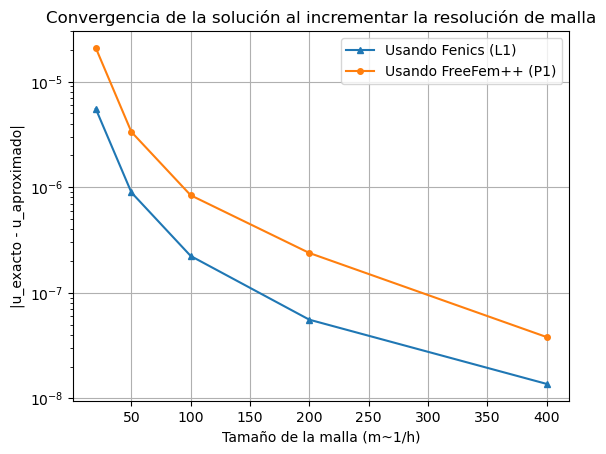

In [6]:
plt.semilogy(df.malla, df.e_fe, marker='^', markersize=4, label = 'Usando Fenics (L1)')
plt.semilogy(df.malla, df.e_ff, marker='o', markersize=4, label = 'Usando FreeFem++ (P1)')
plt.title("Convergencia de la solución al incrementar la resolución de malla")

plt.xlabel("Tamaño de la malla (m~1/h)")
plt.ylabel("|u_exacto - u_aproximado|")
plt.legend()
plt.grid()